<a href="https://colab.research.google.com/github/BagusWichaksono/PCVK_Ganjil_2026/blob/main/Modul1_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**D3 — Pengolahan Citra Dasar, Channel Warna, dan Konversinya**

Mempelajari cara menghubungkan Google Drive di Colab, membaca citra dari Drive/Lokal, memahami channel warna BGR vs RGB, konversi Grayscale/Colormap, resizing, flipping, serta menggambar objek geometri 2D.

**Langkah 1 — Menghubungkan Google Colab dengan Google Drive**

Pada langkah ini, kita melakukan Mounting Google Drive agar Google Colab dapat mengakses berkas gambar yang tersimpan di dalam folder Drive pribadi kita.

In [6]:
from google.colab import drive

# Mounting Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Langkah 2 — Membaca dan Menampilkan Gambar (Image Display & Plotting)**

OpenCV membaca gambar dalam format channel warna **BGR** (Blue, Green, Red). Jika ditampilkan langsung menggunakan `plt.imshow()`, warnanya akan tampak kebiruan/tertukar. Untuk menampilkan warna asli (RGB), kita mengonversinya menggunakan `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

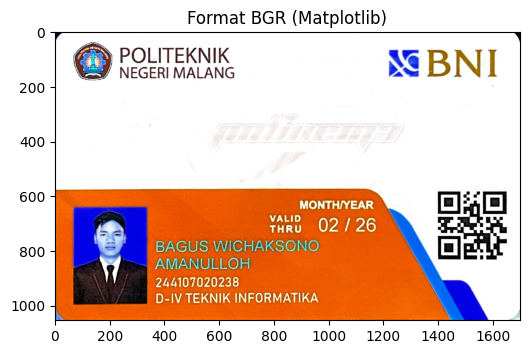

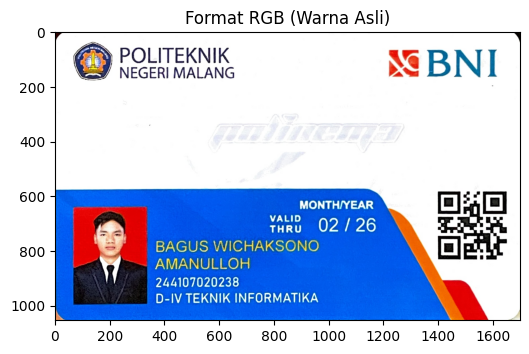

In [7]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Membaca gambar dari Google Drive (Sesuaikan path file gambar Anda)
img = cv.imread('/content/drive/MyDrive/PCVK/KTM.jpg')

# 1. Menampilkan format BGR asli menggunakan Matplotlib (Warna tertukar)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title('Format BGR (Matplotlib)')
plt.show()

# 2. Konversi BGR ke RGB dan tampilkan
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title('Format RGB (Warna Asli)')
plt.show()

**Langkah 3 — Menampilkan Citra Grayscale dan Colormap**

Membaca gambar dalam bentuk Grayscale menggunakan `cv2.IMREAD_GRAYSCALE`. Saat ditampilkan dengan Matplotlib tanpa parameter `cmap`, gambar akan diberi warna semu bawaan (*viridis*). Gunakan `cmap='gray'` untuk menampilkan warna derajat keabuan yang sebenarnya, atau `cmap='magma'` untuk colormap lainnya.

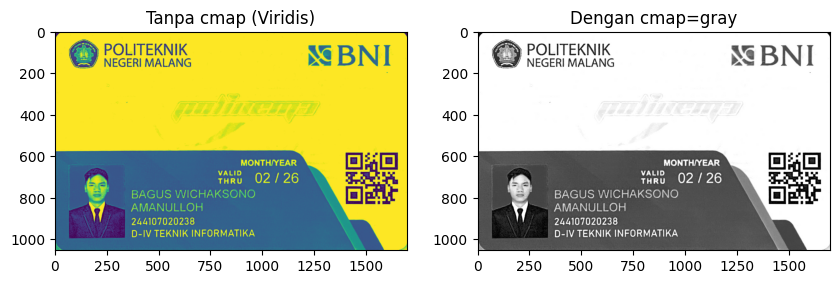

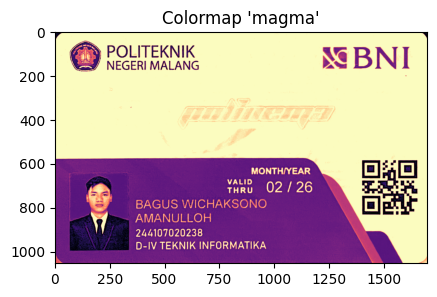

In [8]:
# Membaca gambar langsung dalam bentuk Grayscale
img_gray = cv.imread(
    '/content/drive/MyDrive/PCVK/KTM.jpg', cv.IMREAD_GRAYSCALE
)

plt.figure(figsize=(10, 4))

# Tanpa cmap
plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title('Tanpa cmap (Viridis)')

# Dengan cmap='gray'
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap=gray')

plt.show()

# Menampilkan dengan Colormap 'magma'
plt.figure(figsize=(5, 3))
plt.imshow(img_gray, cmap='magma')
plt.title("Colormap 'magma'")
plt.show()

**Langkah 4 — Pengubahan Ukuran Citra (Resizing)**

Mengubah dimensi gambar menggunakan fungsi `cv2.resize()`. Pada contoh ini, ukuran gambar diubah menjadi 400x250 piksel.

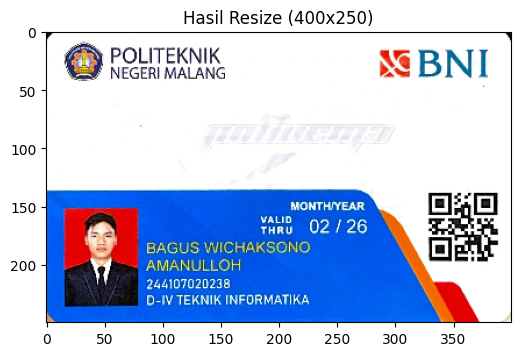

In [9]:
# Resizing gambar menjadi lebar 400 dan tinggi 250
img_small = cv.resize(img_rgb, (400, 250))

plt.figure(figsize=(6, 4))
plt.imshow(img_small)
plt.title('Hasil Resize (400x250)')
plt.show()

**Langkah 5 — Pencerminan Citra (Flipping)**

Mencerminkan posisi piksel gambar menggunakan `cv2.flip()`. Parameter `1` digunakan untuk pencerminan horizontal (kiri-kanan).

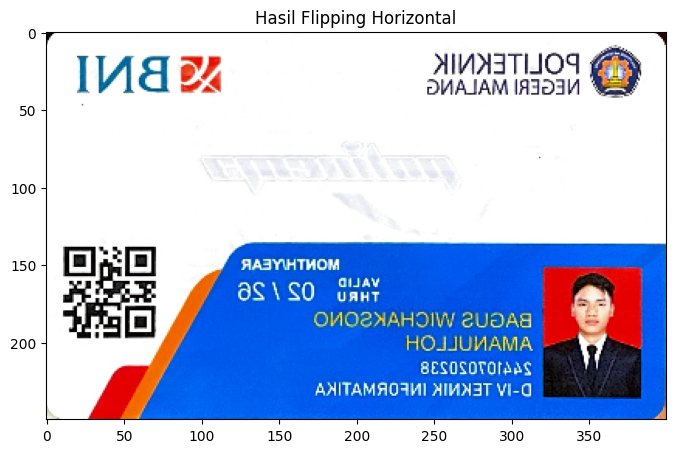

In [10]:
# Flipping horizontal (1 = horizontal, 0 = vertikal, -1 = keduanya)
img_flip = cv.flip(img_small, 1)

# Tampilkan dengan ukuran canvas Matplotlib yang lebih besar
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ax.imshow(img_flip)
plt.title('Hasil Flipping Horizontal')
plt.show()

**Langkah 6 — Membuat Bentuk Geometri 2D Menggunakan OpenCV**

Di langkah ini, kita membuat kanvas hitam polos berukuran 512x512 dengan `np.zeros` bertipe data `int16`, lalu menggambar bentuk persegi panjang, persegi, lingkaran, garis, teks, serta poligon (`polylines`) dengan tipe data `int32`.

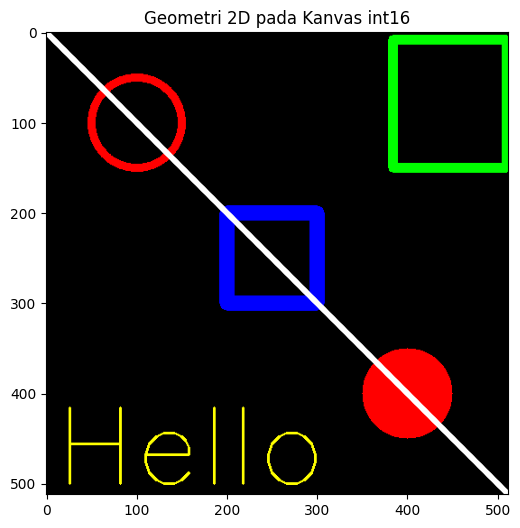

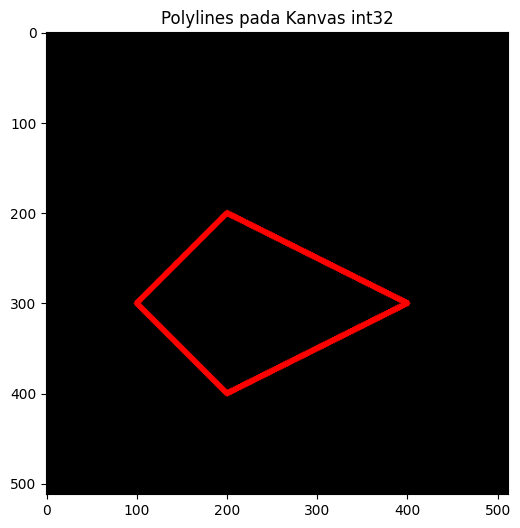

In [11]:
import numpy as np

# 1. Buat kanvas hitam tipe data int16
black_img = np.zeros(shape=(512, 512, 3), dtype=np.int16)

# 2. Tambah Persegi Panjang Hijau (pt1, pt2, color, thickness)
cv.rectangle(
    black_img, pt1=(384, 8), pt2=(510, 150), color=(0, 255, 0), thickness=10
)

# 3. Tambah Persegi Biru
cv.rectangle(
    black_img, pt1=(200, 200), pt2=(300, 300), color=(0, 0, 255), thickness=15
)

# 4. Tambah Lingkaran Merah (center, radius, color, thickness)
cv.circle(
    black_img, center=(100, 100), radius=50, color=(255, 0, 0), thickness=8
)

# 5. Tambah Lingkaran Merah Solid & Garis Diagonal Putih
cv.circle(
    black_img, center=(400, 400), radius=50, color=(255, 0, 0), thickness=-1
)
cv.line(
    black_img,
    pt1=(0, 0),
    pt2=(512, 512),
    color=(255, 255, 255),
    thickness=5,
)

# 6. Tambah Teks
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(
    black_img,
    text='Hello',
    org=(10, 500),
    fontFace=font,
    fontScale=4,
    color=(255, 255, 0),
    thickness=2,
    lineType=cv.LINE_AA,
)

plt.figure(figsize=(6, 6))
plt.imshow(black_img)
plt.title('Geometri 2D pada Kanvas int16')
plt.show()

# 7. Poligon (Polylines) menggunakan kanvas int32
black_img2 = np.zeros(shape=(512, 512, 3), dtype=np.int32)
vertices = np.array(
    [[100, 300], [200, 200], [400, 300], [200, 400]], dtype=np.int32
)
pts = vertices.reshape((-1, 1, 2))

cv.polylines(
    black_img2, [pts], isClosed=True, color=(255, 0, 0), thickness=5
)

plt.figure(figsize=(6, 6))
plt.imshow(black_img2)
plt.title('Polylines pada Kanvas int32')
plt.show()

**PERTANYAAN PRAKTIKUM D3**

**1. Apakah perbedaan gambar yang ditampilkan tanpa dan dengan Matplotlib?**
> Tanpa Matplotlib (`cv2_imshow`), gambar ditampilkan langsung dalam ukuran piksel aslinya tanpa sumbu koordinat. Sedangkan dengan Matplotlib (`plt.imshow`), gambar dimasukkan ke dalam kerangka plot lengkap dengan skala sumbu X (lebar) dan Y (tinggi) piksel, namun perlu konversi manual BGR ke RGB agar warnanya tidak kebiruan.

**2. Apakah perbedaan dan pengaruhnya pembuatan black image antara tipe data int16 dan int32?**
> Perbedaannya terletak pada alokasi memori dan jangkauan nilainya. Tipe `int16` menggunakan memori 2 byte per elemen (rentang -32.768 s.d. 32.767), sedangkan `int32` menggunakan 4 byte (rentang -2.147.483.648 s.d. 2.147.483.647). Tampilannya secara visual sama-sama hitam, namun fungsi OpenCV tertentu seperti `cv2.polylines()` mewajibkan titik koordinat berupa matriks ber-tipe `int32`.

**3. Apakah kegunaan `from google.colab.patches import cv2_imshow`?**
> Berfungsi menggantikan fungsi `cv2.imshow()` bawaan OpenCV yang tidak bisa menampilkan jendela GUI interaktif di lingkungan cloud Google Colab.

**4. Apakah kegunaan `from skimage import io`?**
> Digunakan untuk memanggil modul Input/Output dari pustaka Scikit-Image, yang berfungsi membaca atau mengunduh berkas citra digital dari path file maupun URL tautan web.

**TUGAS PRAKTIKUM D3**

**Nomor 1 — Pengaruh `figsize` terhadap Ukuran Piksel Citra**

Menguji apakah mengubah ukuran kanvas tampilan (`figsize`) mempengaruhi jumlah piksel asli (`img.shape`).

Ukuran piksel asli (shape) sebelum figsize: (1054, 1700, 3)


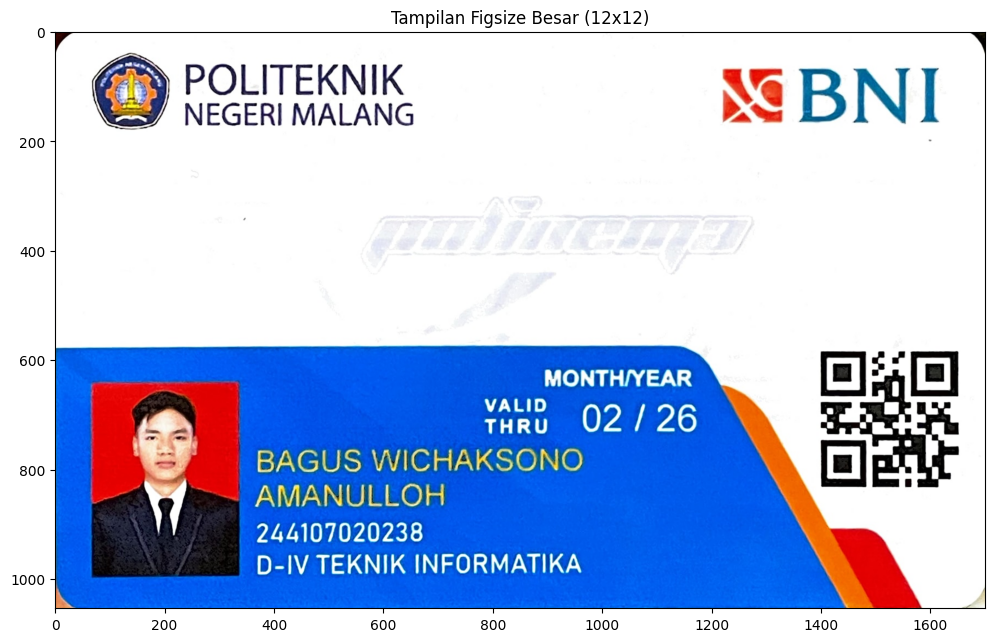

Ukuran piksel asli (shape) setelah figsize: (1054, 1700, 3)


In [12]:
print('Ukuran piksel asli (shape) sebelum figsize:', img_rgb.shape)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.title('Tampilan Figsize Besar (12x12)')
plt.show()

print('Ukuran piksel asli (shape) setelah figsize:', img_rgb.shape)
# Kesimpulan: figsize HANYA mengubah ukuran tampilan kanvas plot di layar, TIDAK mengubah jumlah piksel/dimensi asli citra.

**Nomor 2 — Menampilkan Citra dalam Channel Red-Blue dan Green-Blue**

Mengisolasi kanal warna dengan menolkan kanal yang tidak dipakai.

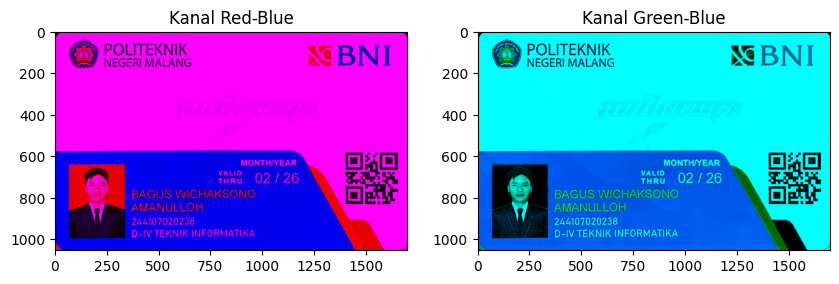

In [13]:
# 1. Channel Red-Blue (Nolkan Channel Green / Indeks 1)
img_RB = img_rgb.copy()
img_RB[:, :, 1] = 0

# 2. Channel Green-Blue (Nolkan Channel Red / Indeks 0)
img_GB = img_rgb.copy()
img_GB[:, :, 0] = 0

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_RB)
plt.title('Kanal Red-Blue')

plt.subplot(1, 2, 2)
plt.imshow(img_GB)
plt.title('Kanal Green-Blue')

plt.show()

**Nomor 3 — Slicing Citra Baris 20-115, Kolom 25-120**

Pemotongan (cropping) area spesifik citra berbasis koordinat piksel.

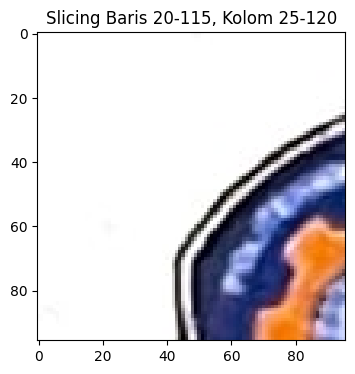

In [14]:
# Cropping baris 20 s.d 115 dan kolom 25 s.d 120
crop_img = img_rgb[20:116, 25:121]

plt.figure(figsize=(4, 4))
plt.imshow(crop_img)
plt.title('Slicing Baris 20-115, Kolom 25-120')
plt.show()

**Nomor 4 — Slicing Baris 5-30, Semua Kolom, Channel Red Saja**

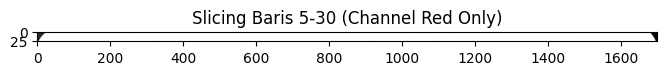

In [15]:
# Slicing baris 5-30, semua kolom, kanal Red (indeks 0)
crop_red = img_rgb[5:31, :, 0]

plt.figure(figsize=(8, 2))
plt.imshow(crop_red, cmap='gray')
plt.title('Slicing Baris 5-30 (Channel Red Only)')
plt.show()

**Nomor 5 — Membuat 5 Kotak Berbagai Ukuran dan Warna Acak (Random)**

In [ ]:
img_random_box = img_rgb.copy()
h, w, _ = img_random_box.shape

# Menjaga konsistensi angka acak
np.random.seed(42)

for _ in range(5):
  # Koordinat acak
  x1, y1 = np.random.randint(0, w - 50), np.random.randint(0, h - 50)
  x2, y2 = x1 + np.random.randint(20, 80), y1 + np.random.randint(20, 80)
  # Warna RGB acak
  color = (
      int(np.random.randint(0, 256)),
      int(np.random.randint(0, 256)),
      int(np.random.randint(0, 256)),
  )

  cv.rectangle(
      img_random_box, (x1, y1), (x2, y2), color, thickness=-1
  )  # Solid box

plt.figure(figsize=(6, 4))
plt.imshow(img_random_box)
plt.title('5 Kotak Warna Acak')
plt.show()

**Nomor 6 — Menampilkan Citra dengan Posisi Terbalik (Vertikal & Horizontal)**

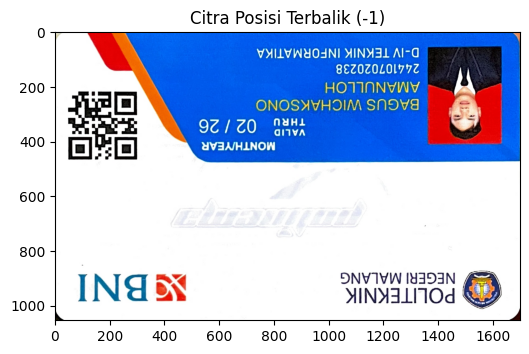

In [16]:
# flipCode = -1 untuk membalik posisi vertikal dan horizontal sekaligus
img_reversed = cv.flip(img_rgb, -1)

plt.figure(figsize=(6, 4))
plt.imshow(img_reversed)
plt.title('Citra Posisi Terbalik (-1)')
plt.show()

**Nomor 7 — Rectangle dan Circle pada Wajah Foto Aktivitas**

Membaca foto aktivitas pribadi lalu menambahkan anotasi rectangle dan circle di area wajah.

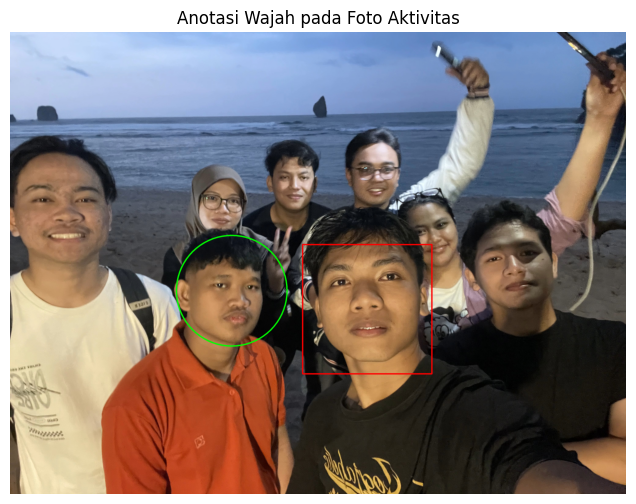

In [22]:
# Membaca foto aktivitas pribadi dari Drive
foto_diri = cv.imread('/content/drive/MyDrive/PCVK/foto_aktivitas.jpg')
foto_diri_rgb = cv.cvtColor(foto_diri, cv.COLOR_BGR2RGB)

h, w, _ = foto_diri_rgb.shape

# 1. Rectangle Merah: Wajah Utama (Depan Tengah - Kaos Hitam)
x_face1 = int(w * 0.58)
y_face1 = int(h * 0.60)
r_face1 = int(h * 0.14)

cv.rectangle(
    foto_diri_rgb,
    pt1=(x_face1 - r_face1, y_face1 - r_face1),
    pt2=(x_face1 + r_face1, y_face1 + r_face1),
    color=(255, 0, 0),
    thickness=8,
)

# 2. Circle Hijau: Wajah Teman Sebelah Kiri (Baju Oranye)
x_face2 = int(w * 0.36)
y_face2 = int(h * 0.56)
r_face2 = int(h * 0.12)

cv.circle(
    foto_diri_rgb,
    center=(x_face2, y_face2),
    radius=r_face2,
    color=(0, 255, 0),
    thickness=8,
)

plt.figure(figsize=(8, 6))
plt.imshow(foto_diri_rgb)
plt.title('Anotasi Wajah pada Foto Aktivitas')
plt.axis('off')
plt.show()

**Nomor 8 & 9 — Rectangle di Sudut Bawah Kiri Kanal B + Teks Nama File**

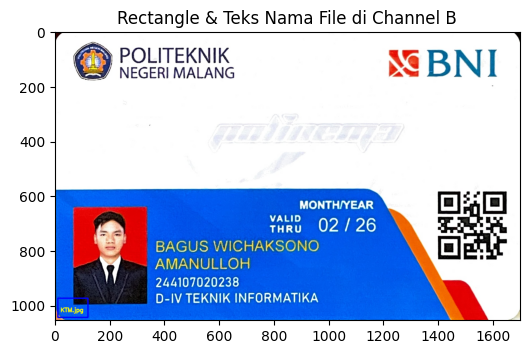

In [23]:
# Mengambil Kanal Blue dari citra (Indeks 2 pada RGB)
blue_channel = img_rgb.copy()

# Membuat rectangle di sudut kiri bawah
h_b, w_b, _ = blue_channel.shape
cv.rectangle(
    blue_channel, (10, h_b - 80), (120, h_b - 10), (0, 0, 255), thickness=3
)

# Menambahkan tulisan nama file citra
cv.putText(
    blue_channel,
    text='KTM.jpg',
    org=(20, h_b - 30),
    fontFace=cv.FONT_HERSHEY_SIMPLEX,
    fontScale=0.7,
    color=(255, 255, 0),
    thickness=2,
    lineType=cv.LINE_AA,
)

plt.figure(figsize=(6, 4))
plt.imshow(blue_channel)
plt.title('Rectangle & Teks Nama File di Channel B')
plt.show()